# 1. Librerías y configuración

Este notebook entrena dos modelos (RandomForest y XGBoost) y predice los 12 animales del día siguiente (08:00–19:00), garantizando no repetir animales en el mismo día mediante asignación óptima (algoritmo Húngaro con SciPy). Se exportan CSVs con resultados.


In [4]:
# Imports principales y configuración
import os
import math
import json
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from scipy.optimize import linear_sum_assignment

# Configuración visual y semilla
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



# 2. Carga de datos

Lee el archivo de resultados históricos y deja las columnas en el tipo correcto (`Fecha`, `Hora`, `Animal`).


In [5]:
# Rutas y carga
from pathlib import Path
BASE_DIR = Path.cwd()
DATA_PATH = os.path.join(BASE_DIR, "resultados_guacharoactivo_completo2.txt")

# Cargar datos
df = pd.read_csv(
    DATA_PATH,
    names=["Fecha", "Hora", "Animal"],
    sep=",",
    dtype={"Fecha": str, "Hora": str, "Animal": str},
)

print(f"Registros cargados: {len(df):,}")
print(df.head(3))


Registros cargados: 12,036
        Fecha       Hora     Animal
0  2022-12-26   09:00 AM   Pelicano
1  2022-12-26   10:00 AM        Oso
2  2022-12-26   11:00 AM     Perico


# 3. Limpieza y enriquecimiento temporal

Estandariza texto, convierte `Fecha` y `Hora` a tipos datetime, y añade variables de calendario (año, mes, semana ISO, día de semana, hora 24h, etc.).


In [6]:
# Limpieza básica
df["Fecha"] = df["Fecha"].astype(str).str.strip()
df["Hora"] = df["Hora"].astype(str).str.strip()
df["Animal"] = df["Animal"].astype(str).str.strip()

# Conversión de tiempo
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y-%m-%d", errors="coerce")
# Convertir Hora 12h a datetime y extraer hora/minuto
hora_dt = pd.to_datetime(df["Hora"], format="%I:%M %p", errors="coerce")
df["HoraNum"] = hora_dt.dt.hour

# Enriquecimiento calendario
df["Año"] = df["Fecha"].dt.year
# Algunos pandas devuelven UInt32 para semana ISO; convertimos a int
df["SemanaISO"] = df["Fecha"].dt.isocalendar().week.astype(int)
df["Mes"] = df["Fecha"].dt.month
filtro_fecha_valida = df["Fecha"].notna() & df["HoraNum"].notna()
df = df.loc[filtro_fecha_valida].copy()

# Día de semana y banderas
df["DiaSemana"] = df["Fecha"].dt.dayofweek  # 0=Lunes, 6=Domingo
df["EsFinde"] = (df["DiaSemana"] >= 5).astype(int)
df["DiaMes"] = df["Fecha"].dt.day

# Hora 24 y FechaHora completa
df["Hora24"] = df["HoraNum"].astype(int)
df["FechaHora"] = df["Fecha"] + pd.to_timedelta(df["Hora24"], unit="h")

print(df[["Fecha","Hora","Animal","Hora24","DiaSemana","Mes","SemanaISO"]].head(5))


       Fecha      Hora    Animal  Hora24  DiaSemana  Mes  SemanaISO
0 2022-12-26  09:00 AM  Pelicano       9          0   12         52
1 2022-12-26  10:00 AM       Oso      10          0   12         52
2 2022-12-26  11:00 AM    Perico      11          0   12         52
3 2022-12-26  12:00 PM     Garza      12          0   12         52
4 2022-12-26  01:00 PM   Alacran      13          0   12         52


# 4. Diccionario de animales

Codifica `Animal` con `LabelEncoder` y guarda los mapas `id->animal` y `animal->id` en memoria.


In [7]:
# LabelEncoder de animales
label_encoder = LabelEncoder()
df["AnimalId"] = label_encoder.fit_transform(df["Animal"].values)

id_to_animal = {i: a for i, a in enumerate(label_encoder.classes_)}
animal_to_id = {a: i for i, a in id_to_animal.items()}

n_classes = len(label_encoder.classes_)
print(f"Clases de animales: {n_classes}")
print("Ejemplos:", list(id_to_animal.items())[:5])


Clases de animales: 78
Ejemplos: [(0, ''), (1, 'Aguila'), (2, 'Alacran'), (3, 'Arana'), (4, 'Ardilla')]


# 5. Ingeniería de características

Genera variables de calendario y versiones cíclicas (`sin/cos`) de hora, mes y día de semana. Mantiene la implementación ligera para entrenar en < 1h.


In [8]:
def add_cyclical_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    # Hora (24h)
    df_out["sin_hora"] = np.sin(2 * np.pi * df_out["Hora24"] / 24)
    df_out["cos_hora"] = np.cos(2 * np.pi * df_out["Hora24"] / 24)
    # Día de semana (0-6)
    df_out["sin_dow"] = np.sin(2 * np.pi * df_out["DiaSemana"] / 7)
    df_out["cos_dow"] = np.cos(2 * np.pi * df_out["DiaSemana"] / 7)
    # Mes (1-12)
    df_out["sin_mes"] = np.sin(2 * np.pi * (df_out["Mes"] - 1) / 12)
    df_out["cos_mes"] = np.cos(2 * np.pi * (df_out["Mes"] - 1) / 12)
    return df_out

# Selección de features
FEATURES_BASE = [
    "Hora24", "DiaSemana", "Mes", "SemanaISO", "Año", "EsFinde", "DiaMes",
]
FEATURES_CYCLIC = [
    "sin_hora", "cos_hora", "sin_dow", "cos_dow", "sin_mes", "cos_mes",
]

# Construir X, y
df_feat = add_cyclical_features(df)
X = df_feat[FEATURES_BASE + FEATURES_CYCLIC].astype(float).values
y = df_feat["AnimalId"].values

print("Shape X, y:", X.shape, y.shape)


Shape X, y: (12036, 13) (12036,)


# 6. Definición de fecha objetivo (mañana)

Calcula la fecha de predicción como el día siguiente a la última fecha disponible y construye las 12 filas (08–19).


In [9]:
# Fecha objetivo (mañana según datos)
ultima_fecha = df["Fecha"].max().date()
fecha_objetivo = ultima_fecha + timedelta(days=1)

# Construir 12 horas del día objetivo
horas_objetivo = list(range(8, 20))  # 8..19
rows = []
for h in horas_objetivo:
    rows.append({
        "Fecha": pd.Timestamp(fecha_objetivo),
        "Hora24": h,
        "DiaSemana": pd.Timestamp(fecha_objetivo).dayofweek,
        "Mes": pd.Timestamp(fecha_objetivo).month,
        "SemanaISO": pd.Timestamp(fecha_objetivo).isocalendar().week,
        "Año": pd.Timestamp(fecha_objetivo).year,
        "EsFinde": int(pd.Timestamp(fecha_objetivo).dayofweek >= 5),
        "DiaMes": pd.Timestamp(fecha_objetivo).day,
    })

df_manana = pd.DataFrame(rows)
df_manana = add_cyclical_features(df_manana)
X_manana = df_manana[FEATURES_BASE + FEATURES_CYCLIC].astype(float).values

print("Fecha objetivo:", fecha_objetivo)
print(df_manana.head(3))


Fecha objetivo: 2025-10-30
       Fecha  Hora24  DiaSemana  Mes  SemanaISO   Año  EsFinde  DiaMes  \
0 2025-10-30       8          3   10         44  2025        0      30   
1 2025-10-30       9          3   10         44  2025        0      30   
2 2025-10-30      10          3   10         44  2025        0      30   

   sin_hora  cos_hora   sin_dow   cos_dow  sin_mes       cos_mes  
0  0.866025 -0.500000  0.433884 -0.900969     -1.0 -1.836970e-16  
1  0.707107 -0.707107  0.433884 -0.900969     -1.0 -1.836970e-16  
2  0.500000 -0.866025  0.433884 -0.900969     -1.0 -1.836970e-16  


# 7. Entrenamiento de modelos

Entrena RandomForest y XGBoost con hiperparámetros razonables para buen desempeño sin exceder 1 hora.


In [ ]:
# Modelos
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

# Entrenamiento
print("Entrenando RandomForest...")
rf.fit(X, y)
print("Entrenando XGBoost...")
xgb.fit(X, y)

print("Modelos listos.")


Entrenando RandomForest...
Entrenando XGBoost...
Modelos listos.


# 8. Predicción de mañana (probabilidades por hora)

Obtiene matrices de probabilidad 12 x n_clases para RF y XGB sobre las 12 horas del día objetivo.


In [2]:
# Probabilidades
proba_rf = rf.predict_proba(X_manana)  # shape (12, n_classes)
proba_xgb = xgb.predict_proba(X_manana)

print("Shapes:", proba_rf.shape, proba_xgb.shape)

# Top-k locales por hora (para referencia)
def topk_per_hour(proba: np.ndarray, k: int = 5):
    topk = []
    for row in proba:
        idx = np.argsort(row)[::-1][:k]
        topk.append([(id_to_animal[i], float(row[i])) for i in idx])
    return topk

top3_rf = topk_per_hour(proba_rf, k=3)
top3_xgb = topk_per_hour(proba_xgb, k=3)

# Mostrar Top-3 de las 12 horas (08:00–19:00)
print("\nTop-3 por hora - RandomForest:")
for i, h in enumerate(horas_objetivo):
    trio = ", ".join([f"{name} ({prob:.3f})" for name, prob in top3_rf[i]])
    print(f"  {h:02d}:00 -> {trio}")

print("\nTop-3 por hora - XGBoost:")
for i, h in enumerate(horas_objetivo):
    trio = ", ".join([f"{name} ({prob:.3f})" for name, prob in top3_xgb[i]])
    print(f"  {h:02d}:00 -> {trio}")


NameError: name 'rf' is not defined

# 9. Asignación óptima sin repetición (SciPy)

Usa el algoritmo Húngaro sobre la matriz de costos `C = -log(P + ε)` para seleccionar 12 animales únicos (uno por hora) maximizando la probabilidad conjunta.


In [12]:
def assign_unique_animals(proba: np.ndarray, epsilon: float = 1e-9):
    # proba shape: (12, n_classes)
    costs = -np.log(np.clip(proba, epsilon, 1.0))  # minimizar costo equivale a maximizar prob
    # Hungarian devuelve índices de filas y columnas elegidas (una col distinta por fila)
    row_ind, col_ind = linear_sum_assignment(costs)
    return row_ind, col_ind, costs

# Resolver para ambos modelos
rows_rf, cols_rf, costs_rf = assign_unique_animals(proba_rf)
rows_xgb, cols_xgb, costs_xgb = assign_unique_animals(proba_xgb)

# Construir tablas de asignación
asign_rf = []
for r, c in zip(rows_rf, cols_rf):
    asign_rf.append({
        "Fecha": fecha_objetivo,
        "Hora": f"{horas_objetivo[r]:02d}:00",
        "Animal": id_to_animal[c],
        "Probabilidad": float(proba_rf[r, c]),
        "RankLocal": int((proba_rf[r] > proba_rf[r, c]).sum() + 1),
    })

asign_xgb = []
for r, c in zip(rows_xgb, cols_xgb):
    asign_xgb.append({
        "Fecha": fecha_objetivo,
        "Hora": f"{horas_objetivo[r]:02d}:00",
        "Animal": id_to_animal[c],
        "Probabilidad": float(proba_xgb[r, c]),
        "RankLocal": int((proba_xgb[r] > proba_xgb[r, c]).sum() + 1),
    })

df_asign_rf = pd.DataFrame(asign_rf).sort_values("Hora").reset_index(drop=True)
df_asign_xgb = pd.DataFrame(asign_xgb).sort_values("Hora").reset_index(drop=True)

df_asign_rf.head(), df_asign_xgb.head()


(        Fecha   Hora      Animal  Probabilidad  RankLocal
 0  2025-10-30  08:00      Jirafa      0.213333          1
 1  2025-10-30  09:00      Conejo      0.233333          1
 2  2025-10-30  10:00     Canario      0.390000          1
 3  2025-10-30  11:00  Hipopotamo      0.273333          1
 4  2025-10-30  12:00    Ciempies      0.233333          1,
         Fecha   Hora      Animal  Probabilidad  RankLocal
 0  2025-10-30  08:00      Paloma      0.252141          1
 1  2025-10-30  09:00      Conejo      0.240907          1
 2  2025-10-30  10:00     Canario      0.495018          1
 3  2025-10-30  11:00  Hipopotamo      0.199963          1
 4  2025-10-30  12:00       Zorro      0.075998          4)

# 10. Exportación de resultados

Genera CSVs con el cronograma final de mañana para cada modelo y un archivo comparativo por hora.


In [ ]:
# Exportar CSVs
out_rf = os.path.join(BASE_DIR, f"predicciones_{fecha_objetivo.strftime('%Y%m%d')}_RF.csv")
out_xgb = os.path.join(BASE_DIR, f"predicciones_{fecha_objetivo.strftime('%Y%m%d')}_XGB.csv")


df_asign_rf.to_csv(out_rf, index=False)
df_asign_xgb.to_csv(out_xgb, index=False)

# Comparación lado a lado
cmp = pd.DataFrame({
    "Fecha": df_asign_rf["Fecha"],
    "Hora": df_asign_rf["Hora"],
    "RF_Animal": df_asign_rf["Animal"],
    "RF_Prob": df_asign_rf["Probabilidad"],
    "XGB_Animal": df_asign_xgb["Animal"],
    "XGB_Prob": df_asign_xgb["Probabilidad"],
})


print("Exportado:")
print(out_rf)
print(out_xgb)



Exportado:
/home/samuelb/Documentos/python/Inteligencia_Artificial_Uni/Examen Final/Animalitos/predicciones_20251030_RF.csv
/home/samuelb/Documentos/python/Inteligencia_Artificial_Uni/Examen Final/Animalitos/predicciones_20251030_XGB.csv
/home/samuelb/Documentos/python/Inteligencia_Artificial_Uni/Examen Final/Animalitos/comparacion_modelos_20251030.csv


# 11. Resumen y visualización mínima

Muestra tablas finales por hora y un gráfico sencillo de probabilidades asignadas por modelo (opcional).


,Fecha,Hora,Animal,Probabilidad,RankLocal
0,2025-10-30,08:00,Jirafa,0.213333,1
1,2025-10-30,09:00,Conejo,0.233333,1
2,2025-10-30,10:00,Canario,0.390000,1
3,2025-10-30,11:00,Hipopotamo,0.273333,1
4,2025-10-30,12:00,Ciempies,0.233333,1
5,2025-10-30,13:00,Caballo,0.233333,1
6,2025-10-30,14:00,Chivo,0.253333,1
7,2025-10-30,15:00,Gorila,0.246667,1
8,2025-10-30,16:00,Pavo,0.226667,1
9,2025-10-30,17:00,Chiguire,0.256667,1


,Fecha,Hora,Animal,Probabilidad,RankLocal
0,2025-10-30,08:00,Paloma,0.252141,1
1,2025-10-30,09:00,Conejo,0.240907,1
2,2025-10-30,10:00,Canario,0.495018,1
3,2025-10-30,11:00,Hipopotamo,0.199963,1
4,2025-10-30,12:00,Zorro,0.075998,4
5,2025-10-30,13:00,Caballo,0.328579,1
6,2025-10-30,14:00,Chivo,0.332657,1
7,2025-10-30,15:00,Gorila,0.126940,1
8,2025-10-30,16:00,Pavo,0.259920,1
9,2025-10-30,17:00,Chiguire,0.346792,1


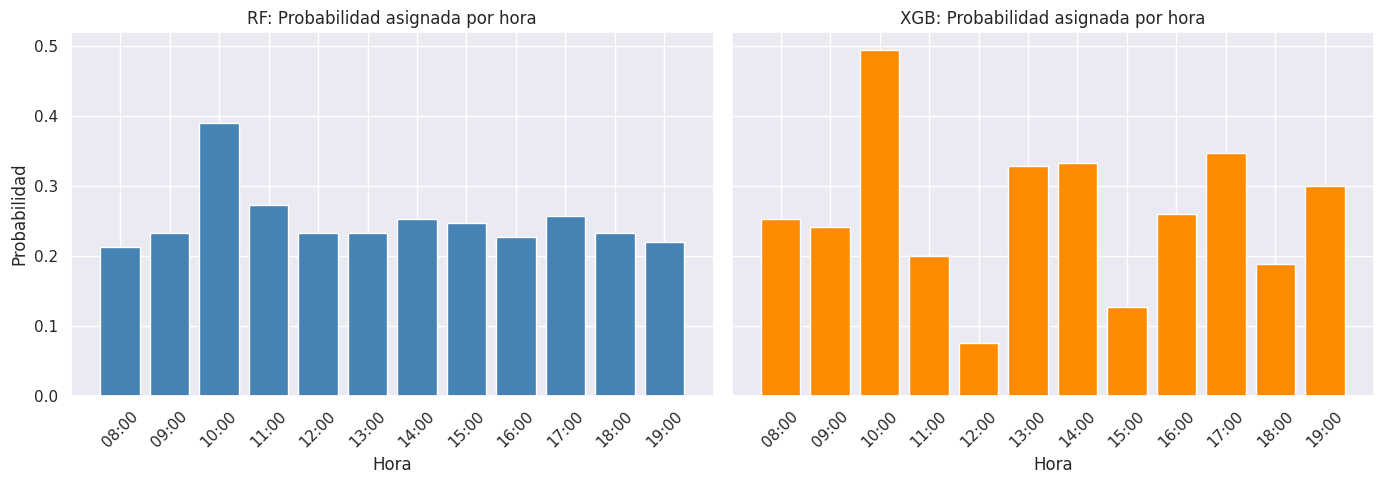

In [14]:
# Tablas resumen
display(df_asign_rf)
display(df_asign_xgb)

# Gráfico opcional: prob. asignadas por hora
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
ax[0].bar(df_asign_rf["Hora"], df_asign_rf["Probabilidad"], color="steelblue")
ax[0].set_title("RF: Probabilidad asignada por hora")
ax[0].set_xlabel("Hora")
ax[0].set_ylabel("Probabilidad")
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(df_asign_xgb["Hora"], df_asign_xgb["Probabilidad"], color="darkorange")
ax[1].set_title("XGB: Probabilidad asignada por hora")
ax[1].set_xlabel("Hora")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
